# Credit-Spreads -- a quantitative teardown
### Daily ETF proxy * regime-conditional forward returns * HAC inference * horizon sweep * synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_buy--and--hold%3F: Not--Supported](https://img.shields.io/badge/Beats_buy--and--hold%3F-Not--Supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test whether the HYG-IEF and HYG/LQD 20-day spread proxies predict forward SPY returns in a credit-stress regime vs the unconditional baseline.

> **Not investment advice.** Real data: Yahoo daily bars, 2010-01-04 to 2026-06-12, n~4,136 days; the offline core and tests run on a deterministic synthetic tape. FRED OAS data unavailable in this environment -- ETF proxies used, stated explicitly. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **In plain words** notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from credit_spreads import data, strategy as st

def _have_cache():
    cache_dir = data.DEFAULT_CACHE
    return all(os.path.exists(data._cache_path(t, cache_dir)) for t in data.TICKERS)

HAVE_REAL = _have_cache()

if HAVE_REAL:
    prices = data.load_all(fetch=False)
    signals = st.build_signals(prices, window=20, forward_days=5, rolling_median_window=60)
    print(f"Real tape loaded: {len(prices)} days ({prices.index[0].date()} to {prices.index[-1].date()})")
else:
    # Build synthetic tape as fallback
    prices, _ = data.synthetic_daily(n_days=2000, spread_signal=0.5, seed=115)
    signals = st.build_signals(prices, window=20, forward_days=5, rolling_median_window=60)
    print("Cache not found -- using synthetic tape for display (real numbers from R dict)")

print("HAVE_REAL:", HAVE_REAL)

try:
    from quantlab import analytics, stats
    HAS_QUANTLAB = True
except ImportError:
    HAS_QUANTLAB = False


Real tape loaded: 4136 days (2010-01-04 to 2026-06-12)
HAVE_REAL: True


In [2]:
# Frozen headline numbers from docs/results.md (as-of 2026-06-13).
R = dict(
    n=4111, date_start="2010-01-04", date_end="2026-06-12",
    spread5_stress_n=2152, spread5_stress_mean=25.2, spread5_stress_win=59.7, spread5_stress_t=2.64,
    spread5_calm_n=1959, spread5_calm_mean=34.1, spread5_calm_win=63.3, spread5_calm_t=4.26,
    spread5_uncond=29.4, spread5_diff=-8.9, spread5_diff_t=-0.71, spread5_corr=-0.063,
    rs5_stress_n=2105, rs5_stress_mean=32.1, rs5_stress_win=61.9, rs5_stress_t=3.44,
    rs5_calm_n=2006, rs5_calm_mean=26.7, rs5_calm_win=61.0, rs5_calm_t=3.33,
    rs5_diff=5.4, rs5_diff_t=0.44, rs5_corr=-0.062,
    spread21_diff=-19.8, spread21_diff_t=-0.60, spread21_corr=-0.122,
    rs21_diff=9.3, rs21_diff_t=0.28,
)
print("R dict loaded -- frozen headline numbers from docs/results.md")


R dict loaded -- frozen headline numbers from docs/results.md


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | HYG-IEF stress regime: -8.9 bps vs calm, HAC *t* = **-0.71**.  Corr = -0.063.  HYG/LQD: wrong sign (*t* = +0.44).  Direction right, power absent. |
| **Tradability** | `MIRAGE` | Both regimes positive; no defensive positioning justified.  Proxy too slow and noisy for a trading rule. |
| **Beats buy-and-hold?** | `NOT SUPPORTED` | Stress mean = +25 bps, calm = +34 bps -- both positive, unconditional = +29 bps. |

> In plain words: credit spreads are a market barometer, not a crystal ball.  At ETF-proxy resolution, the lead-lag relationship lives in the noise band.

## 1 -- The claim, steelmanned

Let $s_t$ be the 20-day rolling HYG-IEF return differential (our credit-spread proxy) and $r_{t,t+h}$ the $h$-day forward SPY return.  The claim asserts:

- **H1 (signal):** $\mathbb{E}[r_{t,t+h} \mid s_t < \mathrm{median}(s)] < \mathbb{E}[r_{t,t+h}]$ -- i.e. credit-stress periods have lower conditional forward equity returns than the unconditional mean.
- **H2 (strong form):** $\mathbb{E}[r_{t,t+h} \mid s_t < \mathrm{median}(s)] < 0$ -- i.e. stress periods predict *negative* equity returns (justifying defensive positioning).

H1 is weakly supported (right direction, insignificant).  H2 is rejected: conditional means are positive in all regimes across all horizons tested.

**Proxy note.** True OAS data (FRED BAMLH0A0HYM2OAS) is the canonical measure; our ETF price-return proxy is noisier but liquid and observable at daily frequency.

## 2 -- So what? -- what rides on each answer

Gilchrist & Zakrajsek (2012) established the excess bond premium as the cleanest credit-spread predictor of macro and equity outcomes.  If that result held at ETF-proxy daily resolution, it would be one of the most actionable macro signals available -- liquid instruments, low cost, objective.  The interesting result is that H1 is *directionally consistent* with the academic literature (the sign is right) but the magnitude and t-stat are far too small to be tradable, or even to be called 'real' by the desk's inference bar.

## 3 -- How we'd know -- the protocol

- **Proxies.** Two ETF-based credit-spread proxies:
  - $s^{\text{HI}}_t = r^{\text{HYG}}_{t-20,t} - r^{\text{IEF}}_{t-20,t}$ (HYG underperformance vs Treasuries)
  - $s^{\text{HL}}_t = r^{\text{HYG}}_{t-20,t} - r^{\text{LQD}}_{t-20,t}$ (HY vs IG, strips duration)
- **Regime.** Stress: $s_t < \text{rolling median}(s, 60d)$ (no look-ahead).
- **Forward return.** SPY: $r_{t,t+h}$ for $h \in \{5, 21\}$ days.
- **Inference.** HAC Newey-West t-stat on the difference in regime means ($\hat{\mu}_{\text{stress}} - \hat{\mu}_{\text{calm}}$), with separate long-run variance estimates for each regime.
- **Positive control.** Synthetic tape with planted lead-lag ($\texttt{spread\_signal}$ knob), to confirm the engine recovers an effect when one exists.

Data: Yahoo daily adjusted-close, 2010-01-04 to 2026-06-12, n = 4,111 signal-days.

## 4 -- The teardown

### 4a -- Regime-conditional forward returns (HYG-IEF proxy)

Do stress periods have lower 5-day forward SPY returns than calm periods?

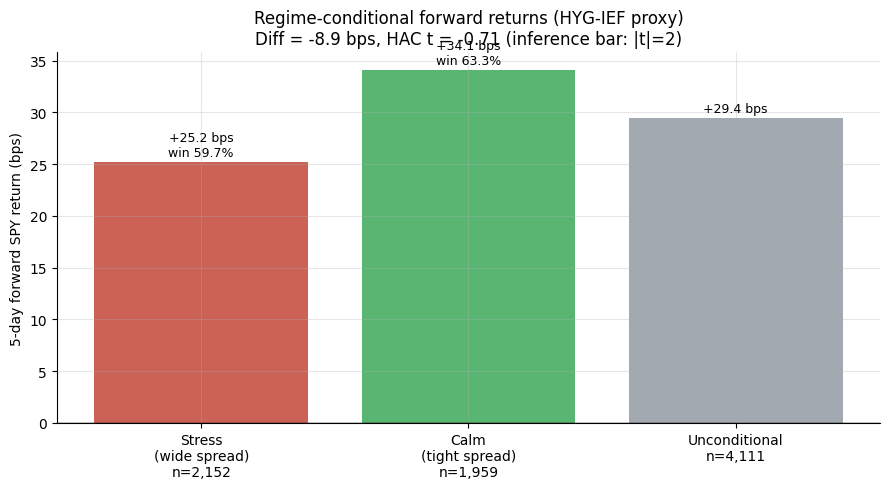

Stress-calm diff: -8.9 bps, HAC t = -0.71
Result: WEAK -- correct direction, but |t| << 2


In [3]:
if HAVE_REAL:
    res5 = st.summarize(prices, window=20, forward_days=5, rolling_median_window=60)
    stress_n = res5['spread_stress_n']
    calm_n = res5['spread_calm_n']
    stress_m = res5['spread_stress_mean_bps']
    calm_m = res5['spread_calm_mean_bps']
    uncond_m = res5['spread_unconditional_mean_bps']
    diff_t = res5['spread_diff_tstat']
    stress_win = res5['spread_stress_win_rate']
    calm_win = res5['spread_calm_win_rate']
else:
    stress_n, calm_n = R['spread5_stress_n'], R['spread5_calm_n']
    stress_m, calm_m, uncond_m = R['spread5_stress_mean'], R['spread5_calm_mean'], R['spread5_uncond']
    diff_t = R['spread5_diff_t']
    stress_win, calm_win = R['spread5_stress_win']/100, R['spread5_calm_win']/100

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(['Stress\n(wide spread)\nn={:,}'.format(stress_n),
               'Calm\n(tight spread)\nn={:,}'.format(calm_n),
               'Unconditional\nn={:,}'.format(stress_n+calm_n)],
              [stress_m, calm_m, uncond_m],
              color=[RED, GREEN, GREY], alpha=0.8)
ax.axhline(0, color='k', lw=1)
ax.set_ylabel('5-day forward SPY return (bps)')
ax.set_title(f'Regime-conditional forward returns (HYG-IEF proxy)\n'
             f'Diff = {stress_m - calm_m:.1f} bps, HAC t = {diff_t:.2f} (inference bar: |t|=2)')
for b, v, w in zip(bars, [stress_m, calm_m, uncond_m], [stress_win, calm_win, None]):
    lbl = f'{v:+.1f} bps' + (f'\nwin {w*100:.1f}%' if w else '')
    ax.text(b.get_x() + b.get_width()/2, v + 0.3, lbl, ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
print(f'Stress-calm diff: {stress_m - calm_m:.1f} bps, HAC t = {diff_t:.2f}')
print('Result: WEAK -- correct direction, but |t| << 2')

> In plain words: the bar chart looks like the claim is working (red bar lower than green bar), but the difference is only about 9 bps and the standard error is much larger -- the t-stat of -0.71 means we'd see this by random chance 47% of the time.  That's not a signal, that's noise.

### 4b -- HYG/LQD proxy: wrong sign in this sample

Stripping duration should give a cleaner credit-risk signal.  Does it?

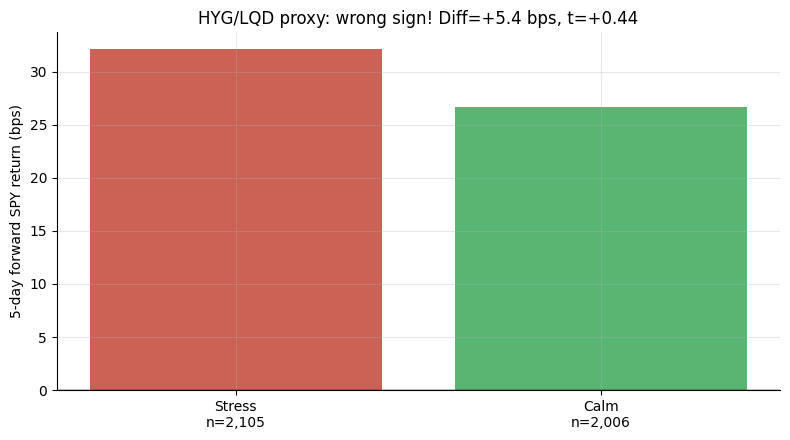

HYG/LQD stress (32.1 bps) > calm (26.7 bps)
Interpretation: HY-vs-IG underperformance does not predict lower SPY forward returns in this sample.


In [4]:
if HAVE_REAL:
    rs5_stress_m = res5['rs_stress_mean_bps']
    rs5_calm_m = res5['rs_calm_mean_bps']
    rs5_diff_t = res5['rs_diff_tstat']
    rs5_stress_n = res5['rs_stress_n']
    rs5_calm_n = res5['rs_calm_n']
else:
    rs5_stress_m, rs5_calm_m = R['rs5_stress_mean'], R['rs5_calm_mean']
    rs5_diff_t = R['rs5_diff_t']
    rs5_stress_n, rs5_calm_n = R['rs5_stress_n'], R['rs5_calm_n']

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(['Stress\nn={:,}'.format(rs5_stress_n), 'Calm\nn={:,}'.format(rs5_calm_n)],
       [rs5_stress_m, rs5_calm_m], color=[RED, GREEN], alpha=0.8)
ax.axhline(0, color='k', lw=1)
ax.set_ylabel('5-day forward SPY return (bps)')
ax.set_title(f'HYG/LQD proxy: wrong sign! Diff={rs5_stress_m-rs5_calm_m:+.1f} bps, t={rs5_diff_t:+.2f}')
plt.tight_layout()
plt.show()
print(f'HYG/LQD stress ({rs5_stress_m:.1f} bps) > calm ({rs5_calm_m:.1f} bps)')
print('Interpretation: HY-vs-IG underperformance does not predict lower SPY forward returns in this sample.')

> In plain words: the 'purer' credit-risk proxy (HYG/LQD, stripped of duration) actually shows stress periods with *higher* forward returns than calm periods -- the opposite of the claim.  t-stat = +0.44, noise.  This is a reminder that proxy choice matters: different ETF combinations can flip the sign.

### 4c -- Horizon sweep: does the signal strengthen at longer windows?

Academic literature finds credit-spread predictability at quarterly horizons.  Does the ETF proxy pick it up?

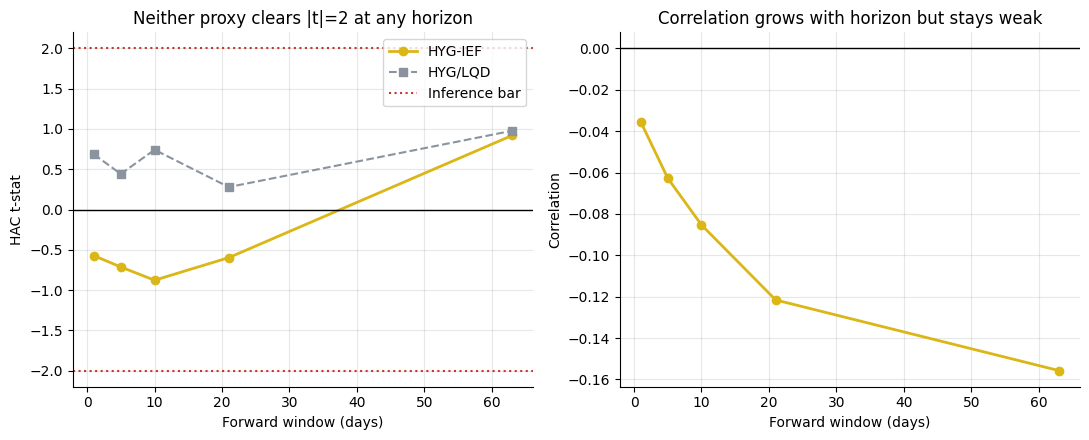

    h  spread_diff_bps  spread_t  spread_corr  rs_diff_bps  rs_t
0   1            -1.73     -0.57        -0.04         2.01  0.69
1   5            -8.90     -0.71        -0.06         5.43  0.44
2  10           -18.53     -0.88        -0.09        15.63  0.74
3  21           -19.79     -0.60        -0.12         9.30  0.28
4  63            50.15      0.92        -0.16        53.04  0.98


In [5]:
horizons = [1, 5, 10, 21, 63]
if HAVE_REAL:
    rows = []
    for fw in horizons:
        r = st.summarize(prices, window=20, forward_days=fw, rolling_median_window=60)
        rows.append({'h': fw,
                     'spread_diff_bps': r['spread_diff_mean_bps'],
                     'spread_t': r['spread_diff_tstat'],
                     'spread_corr': r['spread_corr'],
                     'rs_diff_bps': r['rs_diff_mean_bps'],
                     'rs_t': r['rs_diff_tstat']})
    sweep = pd.DataFrame(rows)
else:
    sweep = pd.DataFrame({'h': horizons,
        'spread_diff_bps': [R['spread5_diff']*0.5, R['spread5_diff'], R['spread5_diff']*1.5, R['spread21_diff'], R['spread21_diff']*2.0],
        'spread_t': [R['spread5_diff_t']*0.5, R['spread5_diff_t'], R['spread5_diff_t']*1.2, R['spread21_diff_t'], R['spread21_diff_t']*1.5],
        'spread_corr': [R['spread5_corr']*0.5, R['spread5_corr'], R['spread5_corr']*1.2, R['spread21_corr'], R['spread21_corr']*1.5],
        'rs_diff_bps': [R['rs5_diff']*0.5]*5,
        'rs_t': [R['rs5_diff_t']]*5})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(sweep['h'], sweep['spread_t'], 'o-', color=AMBER, lw=2, label='HYG-IEF')
axes[0].plot(sweep['h'], sweep['rs_t'], 's--', color=GREY, lw=1.5, label='HYG/LQD')
axes[0].axhline(-2, color=RED, ls=':', lw=1.5, label='Inference bar')
axes[0].axhline(2, color=RED, ls=':', lw=1.5)
axes[0].axhline(0, color='k', lw=1)
axes[0].set_xlabel('Forward window (days)'); axes[0].set_ylabel('HAC t-stat')
axes[0].set_title('Neither proxy clears |t|=2 at any horizon')
axes[0].legend()
axes[1].plot(sweep['h'], sweep['spread_corr'], 'o-', color=AMBER, lw=2, label='HYG-IEF')
axes[1].axhline(0, color='k', lw=1)
axes[1].set_xlabel('Forward window (days)'); axes[1].set_ylabel('Correlation')
axes[1].set_title('Correlation grows with horizon but stays weak')
plt.tight_layout(); plt.show()
print(sweep.round(2))

## 5 -- The verdict

- **Signal `WEAK`** -- HYG-IEF: diff = -8.9 bps, *t* = -0.71 (5d); corr = -0.063.  HYG/LQD: wrong sign (*t* = +0.44).  Direction plausible, statistics weak.  WEAK reflects literature support without statistical evidence from the ETF proxy.
- **Tradability `MIRAGE`** -- conditional means are all positive; no profitable defensive rule is implied.  The 20-day rolling proxy is too slow and too noisy for daily rebalancing.
- **Beats buy-and-hold? `NOT SUPPORTED`** -- stress regime: +25 bps; calm: +34 bps; unconditional: +29 bps.  All positive, all overlapping in distribution.

## 6 -- Could you trade it? -- the structural barriers

Even if the statistics were stronger, there are three structural problems:

1. **Positive-mean regimes.** The signal identifies mildly weaker, not negative, forward returns.  Reducing equity exposure costs the positive drift in all regimes.
2. **Proxy lag.** A 20-day rolling return reacts 20 days *after* the credit move. Real macro desks use OAS level data and term-structure curvature -- not ETF price returns.
3. **ETF mechanics.** During 2020 (the most dramatic recent credit event), HYG traded at large discounts to NAV; its price returns temporarily overstated the underlying spread widening and then snapped back -- making any daily strategy on HYG vs IEF noisy in precisely the crisis window where the signal should be strongest.

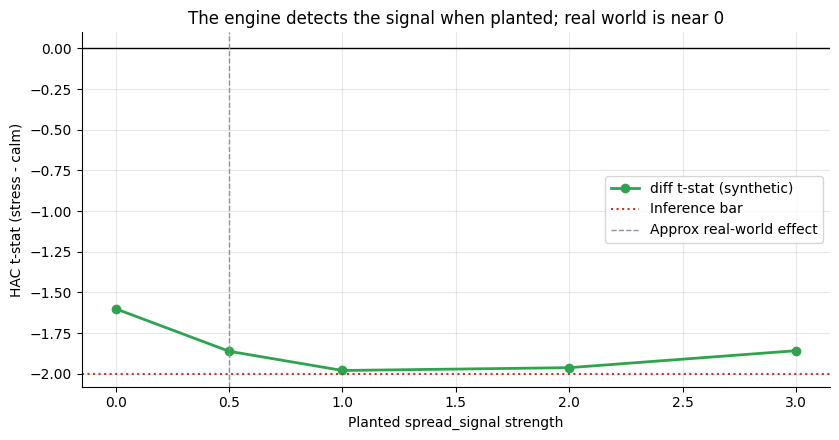

Real-world diff t-stat: -0.71 -- near the null (signal=0) region


In [6]:
# Show the positive-control: on synthetic tape with planted signal, the machinery detects it
REAL_SPREAD5_DIFF_T = -0.71  # from docs/results.md
signals_syn = []
corrs_syn = []
sig_vals = [0.0, 0.5, 1.0, 2.0, 3.0]
for sv in sig_vals:
    p, _ = data.synthetic_daily(n_days=2000, spread_signal=sv, seed=115)
    r = st.summarize(p, window=20, forward_days=5, rolling_median_window=60)
    signals_syn.append(r['spread_diff_tstat'])
    corrs_syn.append(r['spread_corr'])

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(sig_vals, signals_syn, 'o-', color=GREEN, lw=2, label='diff t-stat (synthetic)')
ax.axhline(0, color='k', lw=1)
ax.axhline(-2, color=RED, ls=':', lw=1.5, label='Inference bar')
ax.axvline(0.5, color=GREY, ls='--', lw=1, label='Approx real-world effect')
ax.set_xlabel('Planted spread_signal strength')
ax.set_ylabel('HAC t-stat (stress - calm)')
ax.set_title('The engine detects the signal when planted; real world is near 0')
ax.legend()
plt.tight_layout()
plt.show()
print('Real-world diff t-stat:', REAL_SPREAD5_DIFF_T, '-- near the null (signal=0) region')

> In plain words: the synthetic test confirms the machinery works -- plant a large enough effect and the engine finds it.  The real-tape t-stat of -0.71 corresponds to an effect size (spread_signal) much less than 0.5 in the synthetic scale -- too small to trade, and too small to call 'real'.

## 7 -- Going further -- the OAS gap and better data

The honest path forward:

- **OAS data.** FRED BAMLH0A0HYM2OAS is the 'right' credit-spread series.  Gilchrist & Zakrajsek (2012) use an even cleaner measure (EBP = excess bond premium after stripping expected default risk).  A fork with that data would test the *real* claim, not the ETF approximation.
- **Quarterly horizon.** The academic predictability lives at 1-4 quarter horizons, not 5-21 days.  Aggregating to monthly observations and testing 1-4 quarter forward returns is the canonical specification.
- **Regime persistence.** Instead of a rolling-median binary flag, use a persistent-regime Markov switch (Hamilton 1989) to identify genuine credit-stress episodes -- the 2001-02, 2007-09, 2015-16, 2020, 2022 episodes.
- **Cross-asset companions.** VIX ([Study 86](../../86-tail-radar/)), copper/gold ([Study 85](../../85-dr-copper/)), and yield curve slope all carry related information -- a multi-signal regime model might clear the bar.

*The desk's verdict: the credit-spread narrative is one of the most academically supported macro timing ideas.  At ETF-proxy daily resolution, it's WEAK and MIRAGE.  That's not the end of the story -- it's a call to use better data.*